# BAU cement NPV simulation

Run the BAU cement Monte Carlo simulation and visualize the resulting NPV distribution.

The summary also reports how many simulations have non-negative NPV (NPV >= 0) and how many have negative NPV.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'bau'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,lifetime_years,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_electricity_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_t,levelized_net_margin_eur_per_t
0,0,bau,absolute,not_applicable,1000000.0,25.0,159.145956,14.939217,5.440325,0.736304,...,150000000.0,1.493922e+07,5.440325e+06,8.506046e+06,1.710263e+07,5.286304e+07,5.114875e+07,3.868555e+08,1.067478e+07,36.240148
1,1,bau,absolute,not_applicable,1000000.0,25.0,151.864093,13.907899,5.391308,0.621671,...,150000000.0,1.390790e+07,5.391308e+06,7.488823e+06,2.002749e+07,4.891526e+07,5.426922e+07,4.274476e+08,1.067478e+07,40.042773
2,2,bau,absolute,not_applicable,1000000.0,25.0,162.731823,14.433072,5.398743,0.635506,...,150000000.0,1.443307e+07,5.398743e+06,8.665755e+06,1.884609e+07,4.802583e+07,5.463051e+07,4.204367e+08,1.067478e+07,39.385992
3,3,bau,absolute,not_applicable,1000000.0,25.0,156.283512,14.817433,4.810753,0.625937,...,150000000.0,1.481743e+07,4.810753e+06,7.705387e+06,1.961452e+07,4.983883e+07,5.321308e+07,4.117542e+08,1.067478e+07,38.572633
4,4,bau,absolute,not_applicable,1000000.0,25.0,167.115135,14.905099,5.409093,0.621351,...,150000000.0,1.490510e+07,5.409093e+06,8.712061e+06,1.547021e+07,5.292004e+07,5.258350e+07,3.942019e+08,1.067478e+07,36.928355


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
levelized_net_margin_eur_per_t = results["levelized_net_margin_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        levelized_net_margin_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/t cement"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,Levelized net margin EUR/t cement
count,100000.000000,100000.000000
mean,436.148894,40.857896
std,44.320334,4.151875
min,260.743973,24.426177
5%,363.407776,34.043597
50%,435.859087,40.830747
95%,509.582978,47.737111
max,586.040892,54.899595


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),100000,1.0
1,Negative (NPV < 0),0,0.0


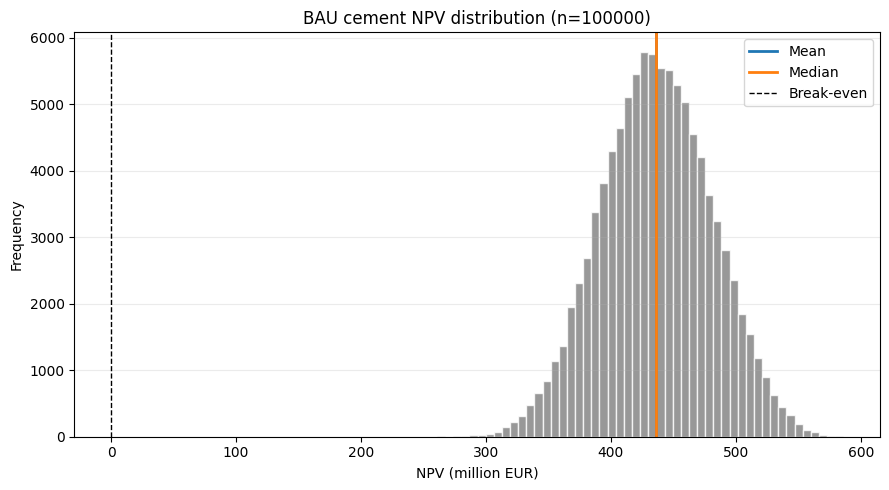

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"BAU cement NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


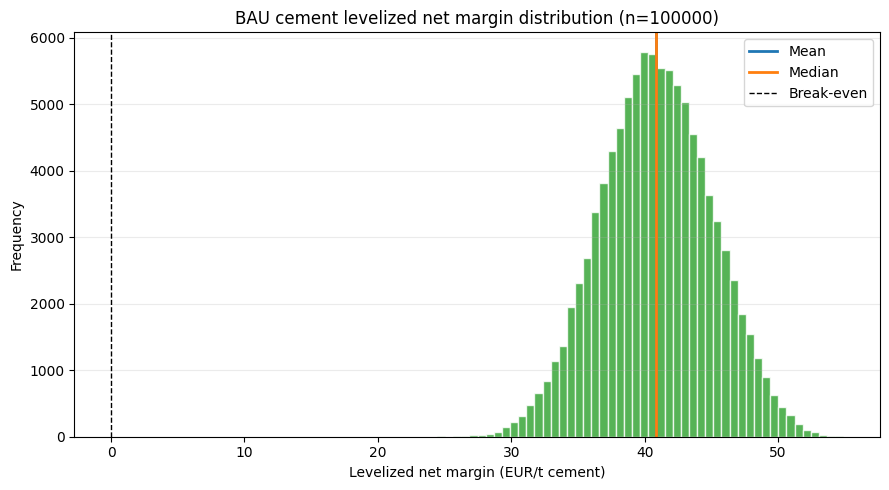

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"BAU cement levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/t cement)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           14.331561
annual_variable_opex_eur         5.167527
annual_fuel_cost_eur             8.068801
annual_electricity_cost_eur     15.928678
annual_emissions_cost_eur       50.657116
annual_net_cash_flow_eur        55.846318
Name: Mean annual value, million EUR, dtype: float64